# Hough Transform Implementation

*In this setion I am going to implement haugh transform fistly using canny edge detector and then*

*using edges to create accumulator matrix based on what we learned in online class*

### imports

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

### Loading the image

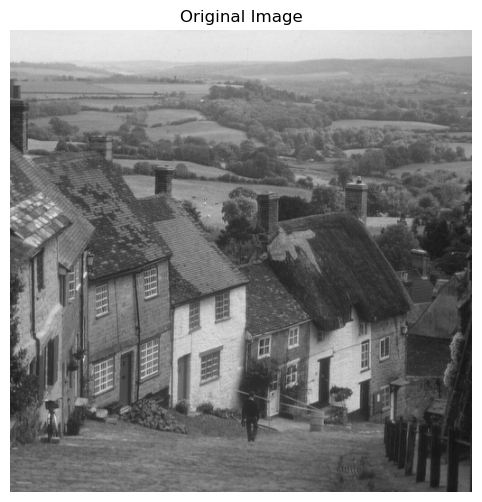

In [5]:
image_path = "hill.png"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

### Canny edge detection with *tuned* parameter

*During coding I tried lower_threshold=50 and upper_threshold=150 and it was too much*

*so i made some changes and increased both of those*

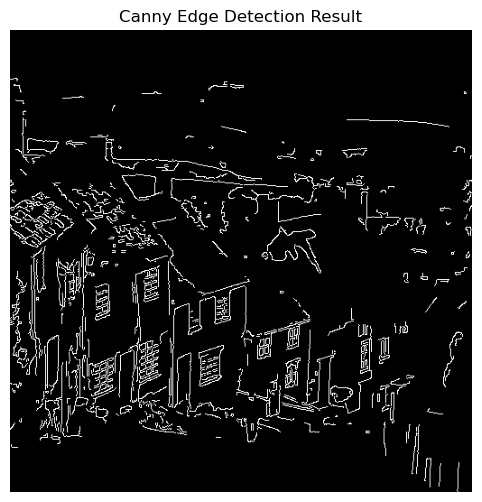

In [28]:
#lower_threshold = 50
#upper_threshold = 150
lower_threshold = 150
upper_threshold = 260
edges = cv2.Canny(gray, lower_threshold, upper_threshold, apertureSize=3)
plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection Result")
plt.axis('off')
plt.show()

### Hough Transform for line detection

In [32]:
rho = 1
theta = np.pi / 180
threshold = 80
min_line_length = 80
max_line_gap = 20

lines = cv2.HoughLinesP(edges, rho, theta, threshold, 
                        minLineLength=min_line_length, 
                        maxLineGap=max_line_gap)
print(f"Number of lines detected: {len(lines) if lines is not None else 0}")

Number of lines detected: 25


### Create accumulator matrix visualization

In [33]:
def create_accumulator_visualization(edges, rho=1, theta_deg=1, threshold=100):
    h, w = edges.shape
    thetas = np.deg2rad(np.arange(-90, 90, theta_deg))
    diag_len = int(np.ceil(np.sqrt(h**2 + w**2)))
    rhos = np.arange(-diag_len, diag_len, rho)
    
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    
    y_idxs, x_idxs = np.nonzero(edges)
    
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        
        for t_idx in range(len(thetas)):
            theta_val = thetas[t_idx]
            rho_val = int(x * np.cos(theta_val) + y * np.sin(theta_val))
            rho_idx = rho_val + diag_len
            if 0 <= rho_idx < len(rhos):
                accumulator[rho_idx, t_idx] += 1
    
    # Scale for display
    accumulator_display = np.log(accumulator + 1)
    accumulator_display = (accumulator_display / accumulator_display.max() * 255).astype(np.uint8)




    # Only show peaks above 50 votes
    accumulator_display[accumulator < 50] = 0  
    return accumulator_display, thetas, rhos

acc_display, thetas, rhos = create_accumulator_visualization(edges, rho=1, theta_deg=1, threshold=100)

### Draw detected lines on black background & on original image

In [34]:
black_bg = np.zeros_like(image_rgb)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(black_bg, (x1, y1), (x2, y2), (0, 0, 255), 2)

result_image = image_rgb.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(result_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

### Create final 4-subplot figure

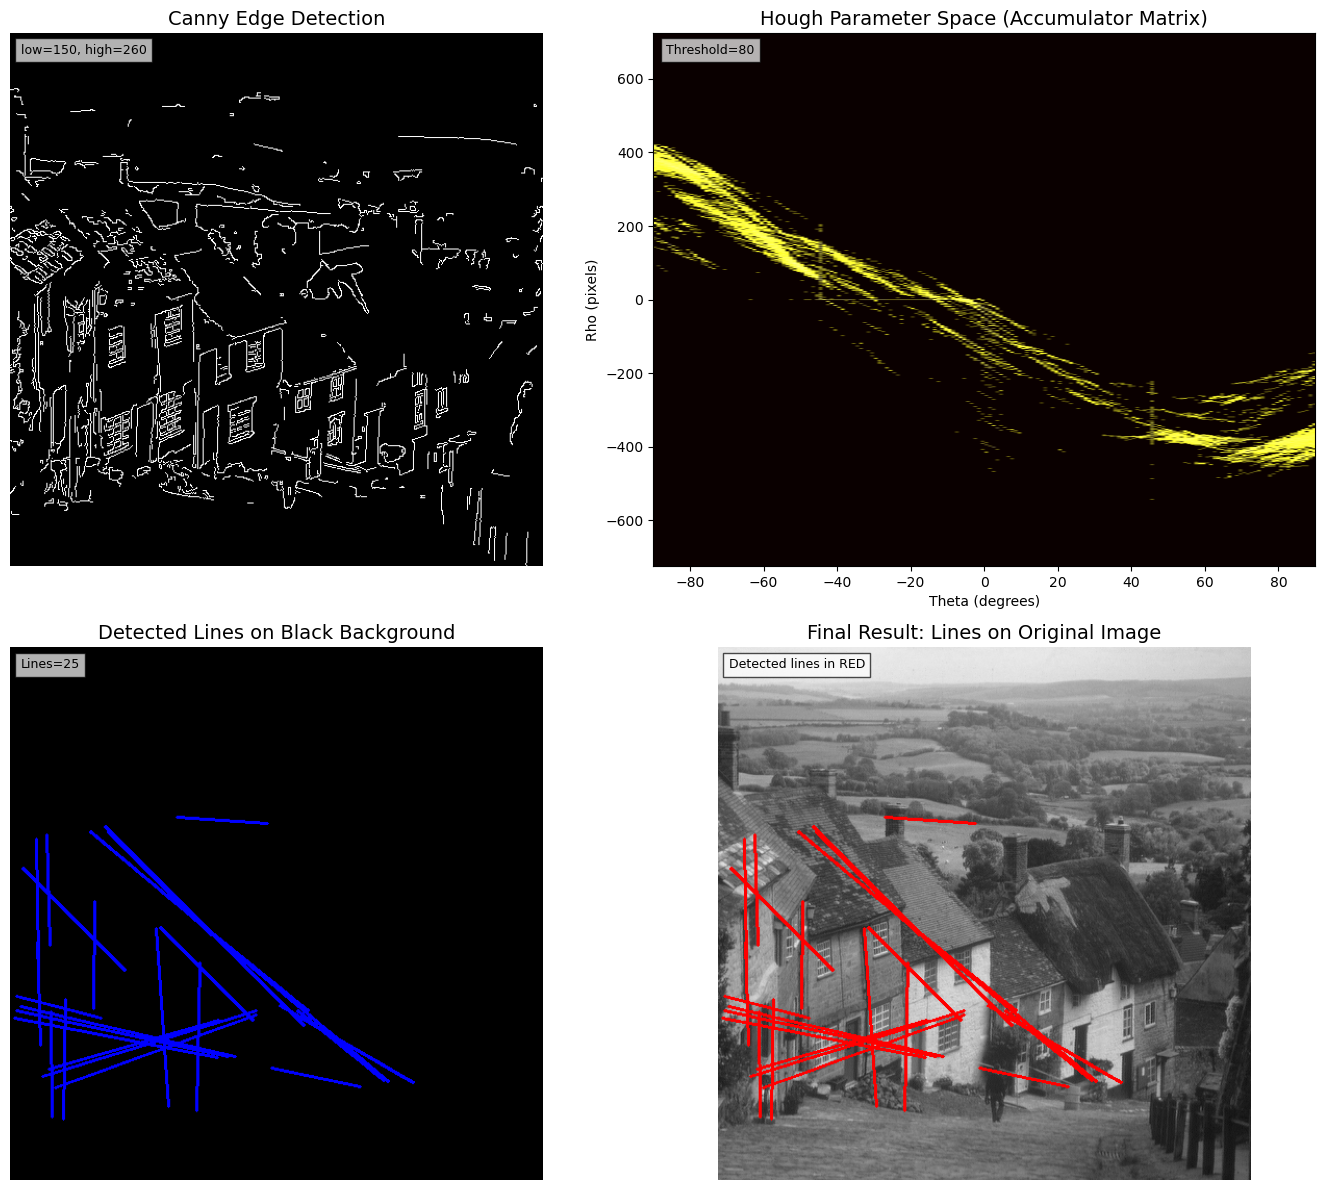

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Subplot 1: Canny edges
axes[0, 0].imshow(edges, cmap='gray')
axes[0, 0].set_title("Canny Edge Detection", fontsize=14)
axes[0, 0].axis('off')
# Add parameter text
axes[0, 0].text(0.02, 0.98, f"low={lower_threshold}, high={upper_threshold}", 
                transform=axes[0, 0].transAxes, fontsize=9, 
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Subplot 2: Hough parameter space (accumulator matrix)
axes[0, 1].imshow(acc_display, cmap='hot', aspect='auto', extent=[-90, 90, -rhos[-1], rhos[-1]])
axes[0, 1].set_title("Hough Parameter Space (Accumulator Matrix)", fontsize=14)
axes[0, 1].set_xlabel("Theta (degrees)")
axes[0, 1].set_ylabel("Rho (pixels)")
# Mark peaks (approximate)
axes[0, 1].text(0.02, 0.98, f"Threshold={threshold}", 
                transform=axes[0, 1].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Subplot 3: Detected lines on black background
axes[1, 0].imshow(black_bg)
axes[1, 0].set_title("Detected Lines on Black Background", fontsize=14)
axes[1, 0].axis('off')
axes[1, 0].text(0.02, 0.98, f"Lines={len(lines) if lines is not None else 0}", 
                transform=axes[1, 0].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Subplot 4: Final result with lines overlaid on original image
axes[1, 1].imshow(result_image)
axes[1, 1].set_title("Final Result: Lines on Original Image", fontsize=14)
axes[1, 1].axis('off')
axes[1, 1].text(0.02, 0.98, "Detected lines in RED", 
                transform=axes[1, 1].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('hough_transform_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis of Parameter Effects on Hough Transform

### Question 1: Effect of Changing the Threshold in Hough Accumulator Matrix

The **Threshold** parameter in Hough Transform determines the minimum number of votes a cell in the accumulator matrix must receive to be considered a valid line.

#### When Threshold Increases:
- **Fewer lines** are detected overall
- Only the strongest, most dominant lines (with many edge points) survive
- Weak or short line segments are eliminated
- **Risk:** Missing some valid but less prominent structural lines (e.g., shorter wall segments)

#### When Threshold Decreases:
- **More lines** are detected
- Many short, fragmented, or noisy lines appear
- Parallel lines close to each other may be detected multiple times
- **Risk:** False positives and cluttered output with many irrelevant lines

---

### Question 2: Effect of Improperly Tuned Canny Thresholds on Hough Space

If Canny thresholds are not set correctly, edge detection includes noise and texture, which directly degrades Hough Transform results.

#### Scenario A: Canny Thresholds Too LOW 

**What happens in Canny:**
- Texture edges (leaves, grass, window details, shadows) are detected as edges
- Many more edge pixels enter the Hough transform (10x-100x more)

**Effect on Hough Parameter Space:**
- Accumulator matrix becomes **dense and noisy**
- Every possible (ρ, θ) receives some votes
- True peaks (structural lines) get **buried among false peaks**
- No clear, distinct peaks visible in the accumulator visualization

**Effect on Output Lines:**
- Dozens or hundreds of lines detected
- Most lines are short and follow texture patterns (random orientations)
- Main structural lines (roof, walls) may still appear but are **surrounded by noise**
- Result is visually cluttered and unusable for analysis

#### Scenario B: Canny Thresholds Too HIGH (e.g., lower=200, upper=300)

**What happens in Canny:**
- Only extremely strong edges survive
- Some valid structural lines with weaker contrast may disappear completely
- Edge map becomes very sparse

**Effect on Hough Parameter Space:**
- Accumulator becomes **sparse** with few active cells
- True peaks may be **missing** or very weak (below threshold)
- Many cells have zero votes

**Effect on Output Lines:**
- Very few lines detected (maybe 0-3 lines)
- Important roof or wall lines may be absent
- Image appears incomplete or "empty"

---
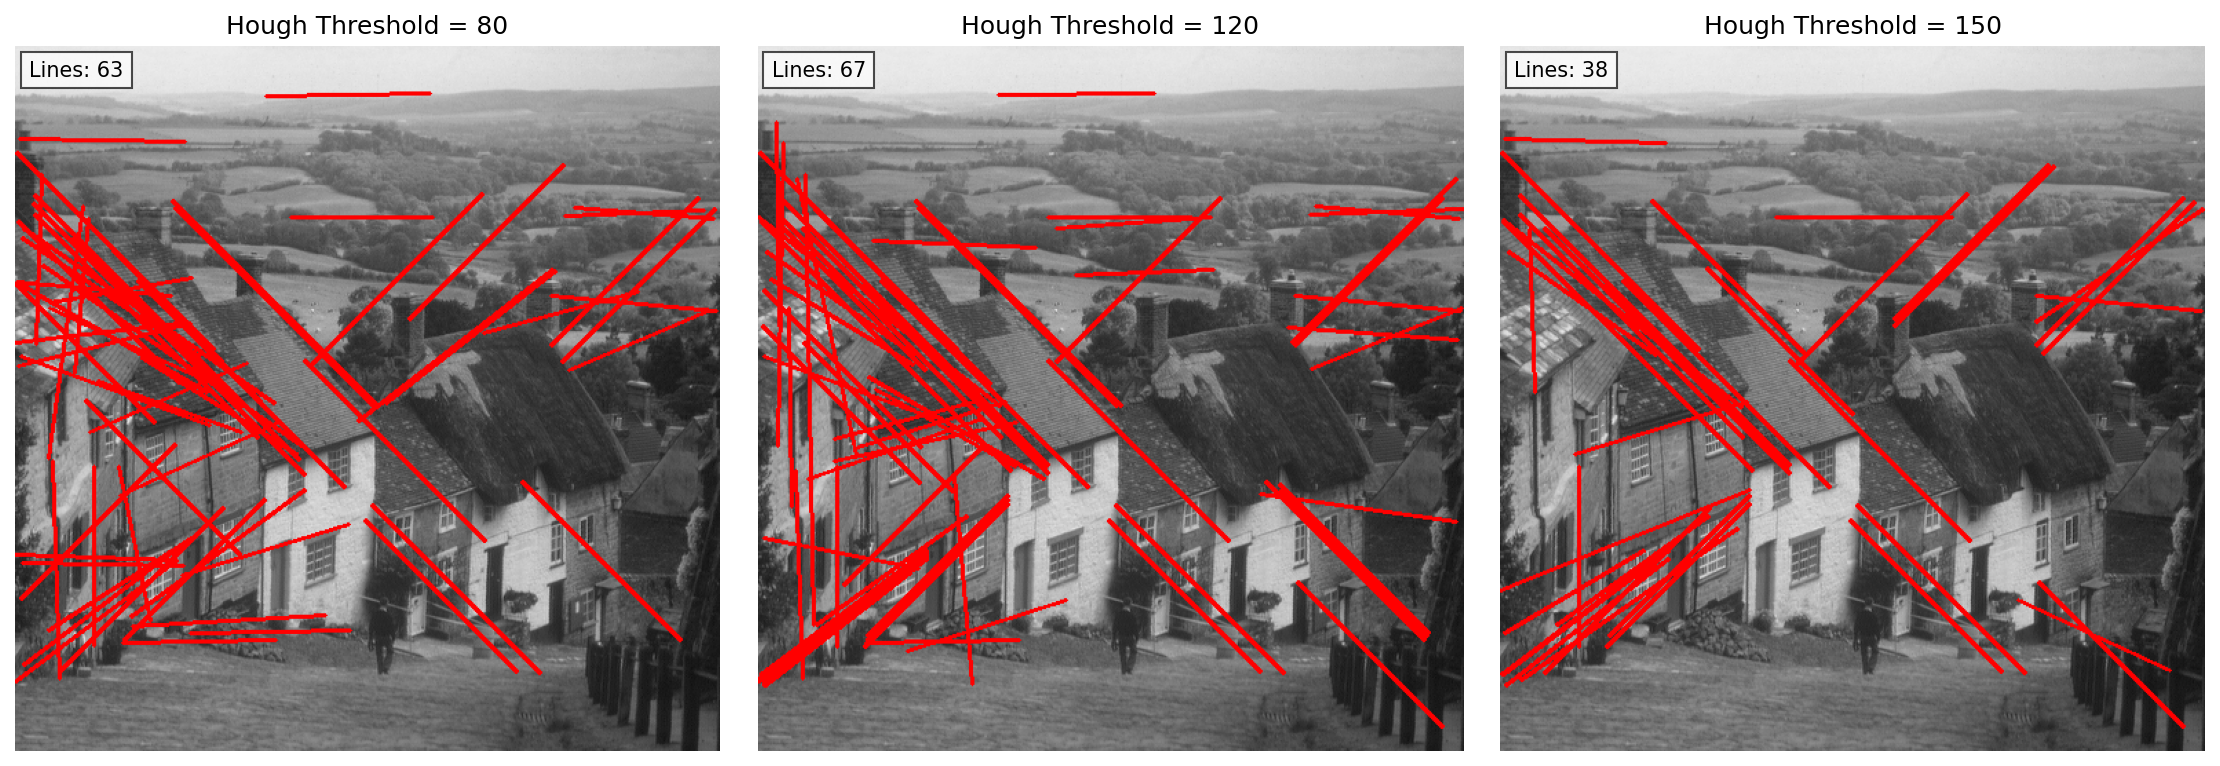